In [1]:
from core.reader import load_experimental_data
from core.calculations import calculate_von_mises_stress


real_experiment_data_folder = r'D:\Users\complex_deformations\P29\experimental_vint'
real_experiment = load_experimental_data(real_experiment_data_folder)
real_experiment = calculate_von_mises_stress(
            real_experiment,
            s_x_col='S_TT',
            s_y_col='S_ZZ',
            s_xy_col='S_TZ',
            new_col_name='S_EQV'
        )

In [3]:
from core.reader import read_ansys_csv

numerical_experiment_voce_hardernng = read_ansys_csv("voce_hardening.csv")

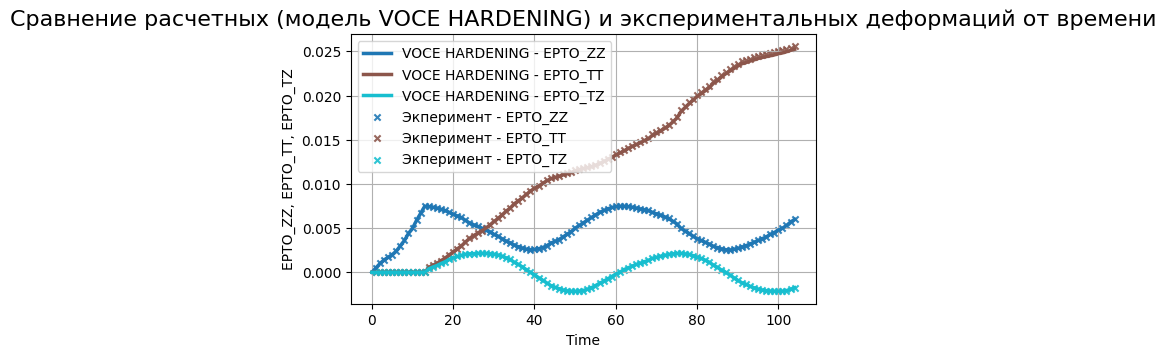

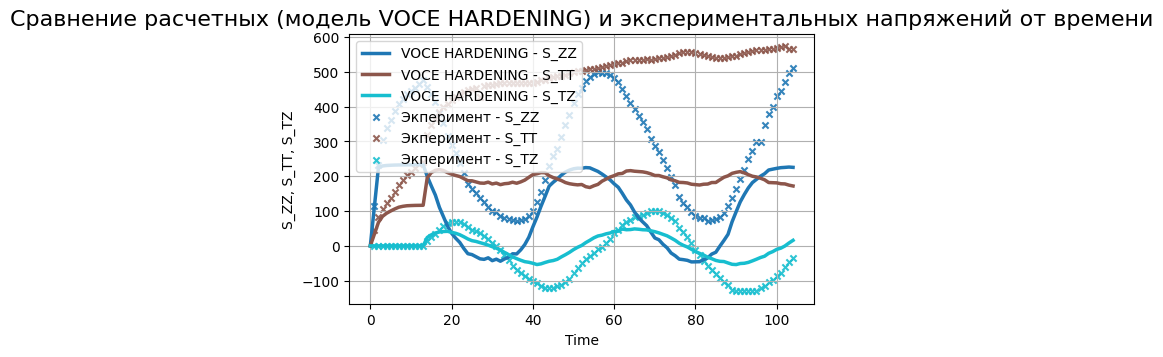

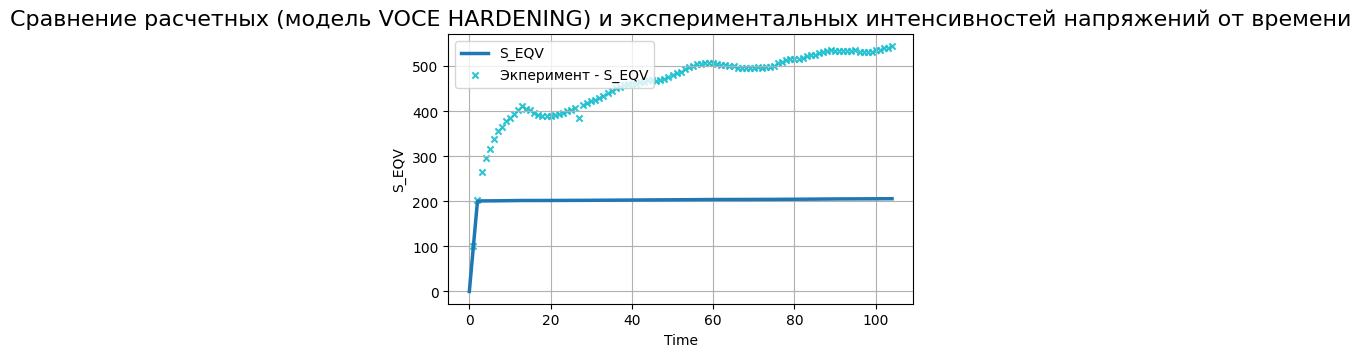

In [4]:
from core.visualizer import plot_xy

model_name = 'VOCE HARDENING'
plot_xy([
        (model_name, numerical_experiment_voce_hardernng)
    ],
    'Time',
    ['EPTO_ZZ', 'EPTO_TT', 'EPTO_TZ'],
    f'Сравнение расчетных (модель {model_name}) и экспериментальных деформаций от времени',
    ('Экперимент', real_experiment)
)

plot_xy([
        (model_name, numerical_experiment_voce_hardernng)
    ],
    'Time',
    ['S_ZZ', 'S_TT', 'S_TZ'],
    f'Сравнение расчетных (модель {model_name}) и экспериментальных напряжений от времени',
    ('Экперимент', real_experiment)
)

plot_xy([
        (model_name, numerical_experiment_voce_hardernng)
    ],
    'Time',
    ['S_EQV'],
    f'Сравнение расчетных (модель {model_name}) и экспериментальных интенсивностей напряжений от времени',
    ('Экперимент', real_experiment)
)

In [5]:
split_time_exp = 14.0
df_exp_stage2 = real_experiment[real_experiment['Time'] > split_time_exp].copy()
df_exp_stage2.reset_index(drop=True, inplace=True)
df_exp_stage2['Time_Local'] = df_exp_stage2['Time'] - df_exp_stage2['Time'].iloc[0]
df_exp_stage2['Sigma_Mean'] = (df_exp_stage2['S_ZZ'] + df_exp_stage2['S_TT']) / 3.0

Параметры среднего напряжения (от ВРЕМЕНИ):
  Amp (p):     71.85 МПа
  Freq (w):    0.1254 рад/с
  Trend (b1):  0.72 МПа/с


<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Arina\AppData\Local\Temp\ipykernel_14840\581325636.py:26: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Аппроксимация среднего напряжения $\sigma_{mean}(t)$')


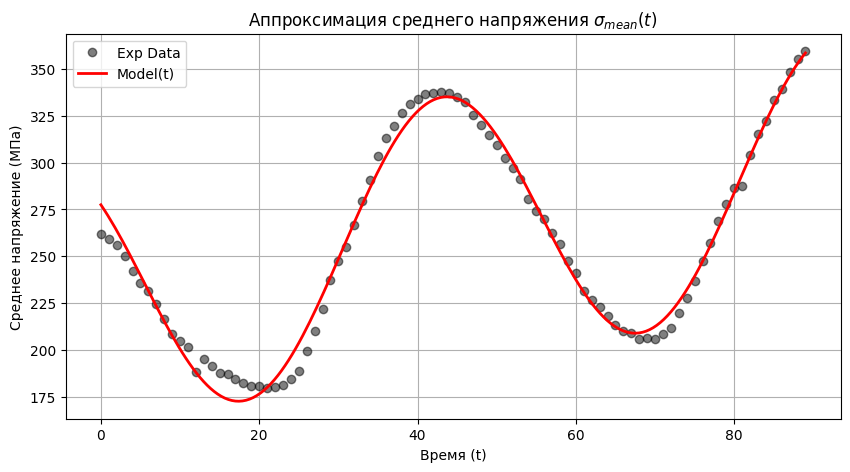

In [6]:
from core.derivatives.stress_approximation import VolumetricModel
import matplotlib.pyplot as plt
import numpy as np


t_vals = df_exp_stage2['Time_Local'].values
sig_vals = df_exp_stage2['Sigma_Mean'].values

vol_model_t = VolumetricModel()

total_time = t_vals.max()
w_guess = (2.0 * 2 * np.pi) / total_time
params_t = vol_model_t.fit(t_vals, sig_vals, guess_w=w_guess)

p_t, w_t, phi_t, b1_t, b2_t = params_t

print("Параметры среднего напряжения (от ВРЕМЕНИ):")
print(f"  Amp (p):     {p_t:.2f} МПа")
print(f"  Freq (w):    {w_t:.4f} рад/с")
print(f"  Trend (b1):  {b1_t:.2f} МПа/с")

plt.figure(figsize=(10, 5))
plt.plot(t_vals, sig_vals, 'ko', alpha=0.5, label='Exp Data')
t_grid = np.linspace(0, total_time, 200)
plt.plot(t_grid, vol_model_t.predict(t_grid), 'r-', lw=2, label='Model(t)')
plt.title('Аппроксимация среднего напряжения $\sigma_{mean}(t)$')
plt.xlabel('Время (t)')
plt.ylabel('Среднее напряжение (МПа)')
plt.grid(True)
plt.legend()
plt.show()

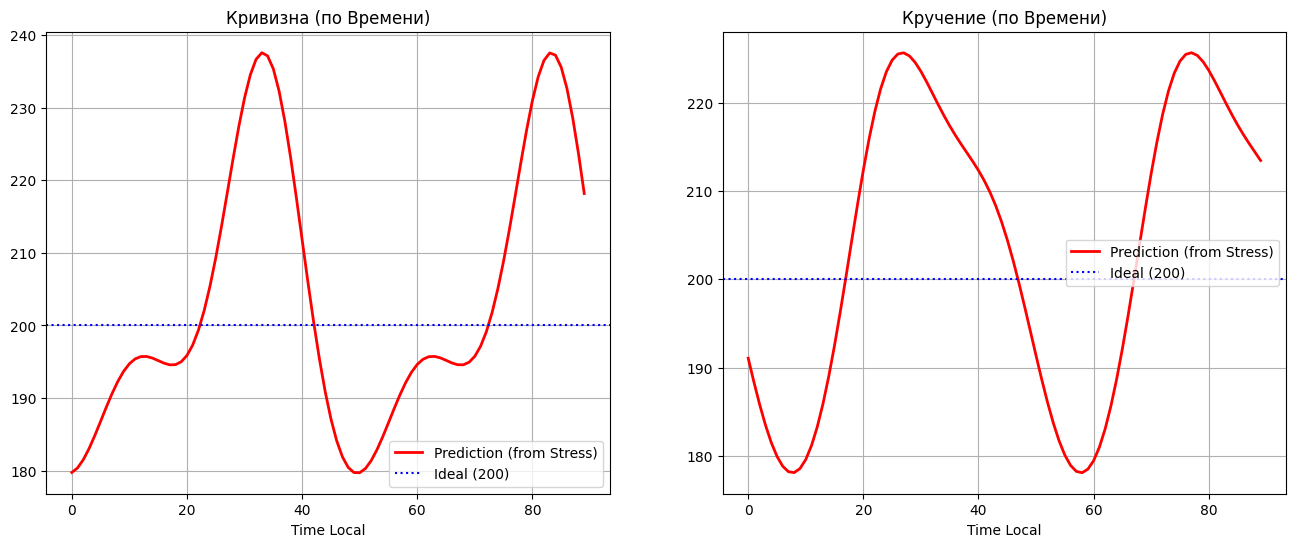

In [7]:
def calculate_geometry_time_based(t_array, vol_model, E=2.05e5, nu=0.29, c=25e-4, a=157e-4):
    p_sig, w, phi, b1_sig, b2_sig = vol_model.params
    k_mat = (1 - 2*nu) / E
    p = p_sig * k_mat
    b1 = b1_sig * k_mat
    alpha = w * t_array
    sqrt3 = np.sqrt(3)
    
    v_ez = -c * w * np.sin(alpha)
    v_et = ((sqrt3 * a * w) / (4 * np.pi)) + 0.5 * c * w * np.sin(alpha)
    v_etz = (sqrt3 / 2) * c * w * np.cos(alpha)
    
    a_ez = -c * (w**2) * np.cos(alpha)
    a_et = 0.5 * c * (w**2) * np.cos(alpha)
    a_etz = -(sqrt3 / 2) * c * (w**2) * np.sin(alpha)

    j_ez = c * (w**3) * np.sin(alpha)
    j_et = -0.5 * c * (w**3) * np.sin(alpha)
    j_etz = -(sqrt3 / 2) * c * (w**3) * np.cos(alpha)
    
    arg_emp = w * t_array + phi
    d_delta = -p * w * np.sin(arg_emp) + b1
    dd_delta = -p * (w**2) * np.cos(arg_emp)
    ddd_delta = p * (w**3) * np.sin(arg_emp)

    V1 = v_ez - d_delta
    A1 = a_ez - dd_delta
    J1 = j_ez - ddd_delta

    v_ni2_id = (a * w) / (2 * np.pi)
    
    V2 = v_ni2_id - sqrt3 * d_delta
    A2 = 0.0 - sqrt3 * dd_delta
    J2 = 0.0 - sqrt3 * ddd_delta
    
    V3 = (2/sqrt3) * v_etz
    A3 = (2/sqrt3) * a_etz
    J3 = (2/sqrt3) * j_etz
    
    V = np.column_stack((V1, V2, V3))
    A = np.column_stack((A1, A2, A3))
    J = np.column_stack((J1, J2, J3))
    
    cross_va = np.cross(V, A)
    num_k = np.linalg.norm(cross_va, axis=1)
    den_k = np.linalg.norm(V, axis=1)**3
    kappa = num_k / den_k
    
    num_t = np.sum(cross_va * J, axis=1)
    den_t = np.linalg.norm(cross_va, axis=1)**2
    tau = num_t / den_t
    
    return kappa, tau

k_pred, t_pred = calculate_geometry_time_based(t_vals, vol_model_t)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(t_vals, k_pred, 'r-', lw=2, label='Prediction (from Stress)')
ax1.axhline(200, color='b', linestyle=':', label='Ideal (200)')
ax1.set_title('Кривизна (по Времени)')
ax1.set_xlabel('Time Local')
ax1.grid(True)
ax1.legend()

ax2.plot(t_vals, np.abs(t_pred), 'r-', lw=2, label='Prediction (from Stress)')
ax2.axhline(200, color='b', linestyle=':', label='Ideal (200)')
ax2.set_title('Кручение (по Времени)')
ax2.set_xlabel('Time Local')
ax2.grid(True)
ax2.legend()

plt.show()